# nos so estamos a tratar dos do treino , depois ver se e suposto limpar tambem o teste eo validacao 

# Data Exploration

1. ✅ Data Exploration        ← já fizemos
2. 🔄 Data Preprocessing     ← próximo passo
3.    Corpus Split            ← train/validation
4.    Feature Engineering     ← BoW, Word2Vec, Transformers
5.    Classification Models   ← ML clássico + Transformers
6.    Avaliação & Análise     ← métricas e conclusões
7.    Predições no test.csv   ← ficheiro pred_xx.csv final

FAZER MELHOR O DATA EXPLORATION PARA CONFIRMAR  O QUE MANTEMOS NO DATA PREPROCESSING OU SE ATE ACRESCENTAMOS ( DEPOIS LIGARA MARIA SE O NOSSO PREPROCESSING ESRTA BEM), QUANTOS DATA PRE PROCESSING FAZEMOS PORQUE EXISTE CERTOS MODELOS QUE JA TEM CERTAS COISAS DO DATA PRE PROCESSING E LIDAM MAL QUANDO IMPLEMENTAS OUTRA VEZ ( MAS MESMO ASSIM ACHO QUE DEVIAMOS FAZER PIPELINE DE BASELINE) E DEPOIS  APLICAR PARA OS ESPICIFICOS , DECIDIR SE FAZEMOS CORPUS SPLIT ANTES OU DEPOIS DO PRE PORCESSING ( EM PRINCIPIO DEPOIS ) ,FAZEMOS O PRE PROCESSING  SO NO TREINO OU TAMBEM FAZEMOS NA VALIDACAO  OU NO TESTE , DECIDIR SE LEMANIZATION OU O OUTRO , DECIDIR WORD_TOKENIZE OU SPLIT(CROACIA), ANALISAR OS TWETS SO COM UMA PALAVRA E TRATALOS , TRATAR DOS EMOJIS 

In [1]:
!pip install nltk


In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

...

Ellipsis

In [3]:
STOP = set(stopwords.words('english'))

# Palette consistente com as 3 classes
CLASS_COLORS = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
CLASS_NAMES  = {0: 'Bearish (0)', 1: 'Bullish (1)', 2: 'Neutral (2)'}

In [4]:
df = pd.read_csv('train.csv')  

In [5]:
print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'Tipos:\n{df.dtypes}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head(10)

Shape: (9543, 2)
Colunas: ['text', 'label']
Tipos:
text     object
label     int64
dtype: object

Missing values:
text     0
label    0
dtype: int64


,text,label
0,$BYND - JPMorgan reels in expectations on Beyo...,0
1,$CCL $RCL - Nomura points to bookings weakness...,0
2,"$CX - Cemex cut at Credit Suisse, J.P. Morgan ...",0
3,$ESS: BTIG Research cuts to Neutral https://t....,0
4,$FNKO - Funko slides after Piper Jaffray PT cu...,0
5,$FTI - TechnipFMC downgraded at Berenberg but ...,0
6,$GM - GM loses a bull https://t.co/tdUfG5HbXy,0
7,$GM: Deutsche Bank cuts to Hold https://t.co/7...,0
8,$GTT: Cowen cuts to Market Perform,0
9,$HNHAF $HNHPD $AAPL - Trendforce cuts iPhone e...,0


# Duplicados

In [6]:
# ── Duplicados ────────────────────────────────────────────────────────────────
duplicados_exatos = df.duplicated(subset='text').sum()
duplicados_com_label = df.duplicated(subset=['text', 'label']).sum()

print(f'Tweets duplicados (texto igual): {duplicados_exatos}')
print(f'Tweets duplicados (texto + label igual): {duplicados_com_label}')

# Ver os duplicados
if duplicados_exatos > 0:
    mask = df.duplicated(subset='text', keep=False)
    print(f'\nExemplos de tweets duplicados:')
    print(df[mask][['text','label']].sort_values('text').head(10).to_string())
    
    # Caso especial: mesmo tweet com labels diferentes (perigoso!)
    conflitos = df[mask].groupby('text')['label'].nunique()
    conflitos = conflitos[conflitos > 1]
    print(f'\nTweets com labels contraditórias (mesmo texto, label diferente): {len(conflitos)}')
    if len(conflitos) > 0:
        print(df[df['text'].isin(conflitos.index)][['text','label']].sort_values('text').head(10).to_string())

Tweets duplicados (texto igual): 0
Tweets duplicados (texto + label igual): 0


## 1. Distribuição das Classes

importante para ver se as classes estao desbalenceadas porque se tiverem é para balenciar 

Se por exemplo 60% dos tweets forem Neutral, os teus modelos vão ter tendência a classificar tudo como Neutral.

=== Contagem por classe ===
  Bearish (0): 1,442 tweets  (15.1%)
  Bullish (1): 1,923 tweets  (20.1%)
  Neutral (2): 6,178 tweets  (64.7%)


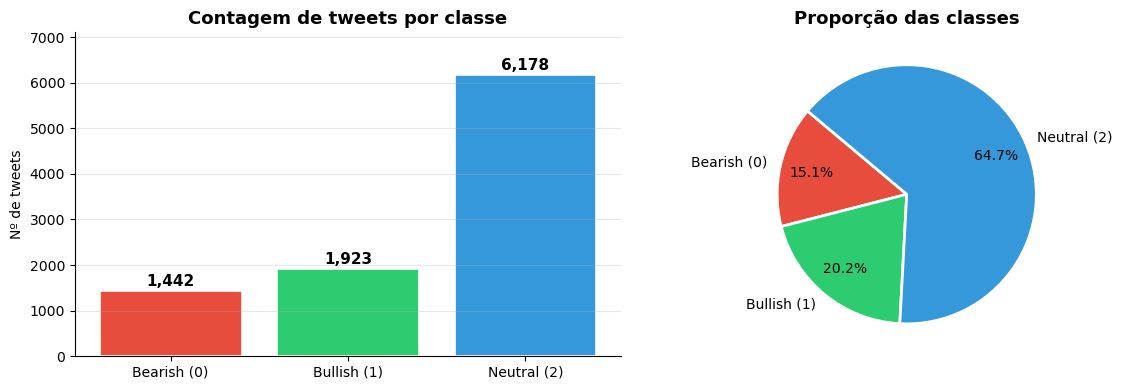


⚠️  Baseline (majority class): 64.7% — qualquer modelo deve superar este valor.


In [ ]:
# ── Distribuição das classes ──────────────────────────────────────────────────
label_counts = df['label'].value_counts().sort_index()
label_pct    = (label_counts / len(df) * 100).round(2)

print('=== Contagem por classe ===')
for lbl, cnt in label_counts.items():
    print(f'  {CLASS_NAMES[lbl]}: {cnt:,} tweets  ({label_pct[lbl]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = [CLASS_COLORS[i] for i in label_counts.index]
bars = axes[0].bar([CLASS_NAMES[i] for i in label_counts.index],
                   label_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Contagem de tweets por classe', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nº de tweets')
axes[0].set_ylim(0, label_counts.max() * 1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Pie chart
axes[1].pie(label_counts.values,
            labels=[CLASS_NAMES[i] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors,
            startangle=140, pctdistance=0.75,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção das classes', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Majority class baseline
majority_acc = label_counts.max() / len(df) * 100
print(f'\n⚠️  Baseline (majority class): {majority_acc:.1f}% — qualquer modelo deve superar este valor.')

## 2. Análise do Comprimento dos Tweets

=== Estatísticas de comprimento (chars / palavras) ===
       n_chars  n_words
count   9543.0   9543.0
mean      85.8     12.2
std       35.1      4.7
min        2.0      1.0
25%       58.0      9.0
50%       79.0     11.0
75%      120.0     15.0
max      190.0     32.0


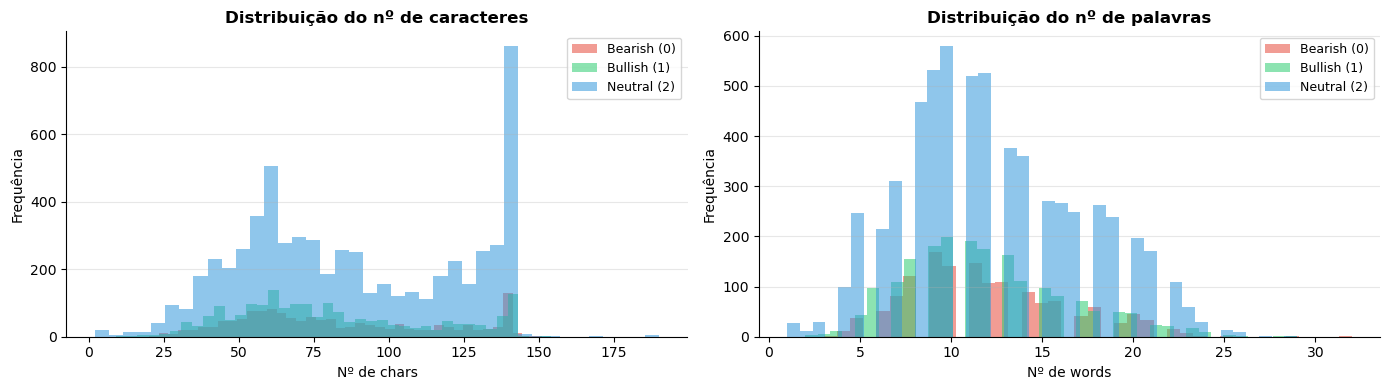


=== Comprimento médio por classe ===
             n_chars  n_words
label                        
Bearish (0)     83.3     12.0
Bullish (1)     80.4     11.9
Neutral (2)     88.1     12.3


In [ ]:
# ── Comprimento dos tweets ────────────────────────────────────────────────────
df['n_chars']  = df['text'].str.len()
df['n_words']  = df['text'].str.split().str.len()
df['n_tokens'] = df['text'].apply(lambda x: len(word_tokenize(str(x))))

print('=== Estatísticas de comprimento (chars / palavras) ===')
print(df[['n_chars', 'n_words']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for metric, ax, title in [
    ('n_chars', axes[0], 'Distribuição do nº de caracteres'),
    ('n_words', axes[1], 'Distribuição do nº de palavras')
]:
    for lbl in [0, 1, 2]:
        subset = df[df['label'] == lbl][metric]
        ax.hist(subset, bins=40, alpha=0.55,
                color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric.replace('n_', 'Nº de '))
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()

# Por classe
print('\n=== Comprimento médio por classe ===')
print(df.groupby('label')[['n_chars', 'n_words']].mean().round(1).rename(index=CLASS_NAMES))

## 3. Vocabulário Global

In [9]:
# ── Vocabulário ───────────────────────────────────────────────────────────────
def tokenize_clean(text):
    """Tokeniza, lowercase, remove pontuação e stopwords."""
    text  = str(text).lower()
    text  = re.sub(r'http\S+|www\S+', '', text)       # URLs
    text  = re.sub(r'@\w+|#\w+', '', text)            # @mentions e #hashtags
    text  = re.sub(r'[^a-z\s]', ' ', text)            # Apenas letras
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 2]

all_tokens = []
for txt in df['text']:
    all_tokens.extend(tokenize_clean(txt))

vocab      = set(all_tokens)
freq       = Counter(all_tokens)
top50      = freq.most_common(50)

print(f'Total de tokens (sem stopwords): {len(all_tokens):,}')
print(f'Vocabulário único (palavras distintas): {len(vocab):,}')
print(f'\n🔝 Top 20 palavras mais frequentes:')
for word, cnt in top50[:20]:
    print(f'   {word:<20} {cnt:>5}')

Total de tokens (sem stopwords): 73,385
Vocabulário único (palavras distintas): 14,016

🔝 Top 20 palavras mais frequentes:
   stock                  611
   new                    417
   results                374
   market                 359
   says                   349
   earnings               346
   inc                    316
   china                  311
   dividend               292
   price                  290
   stocks                 279
   year                   274
   reports                259
   trade                  252
   buy                    237
   deal                   234
   oil                    233
   shares                 223
   revenue                218
   beats                  209


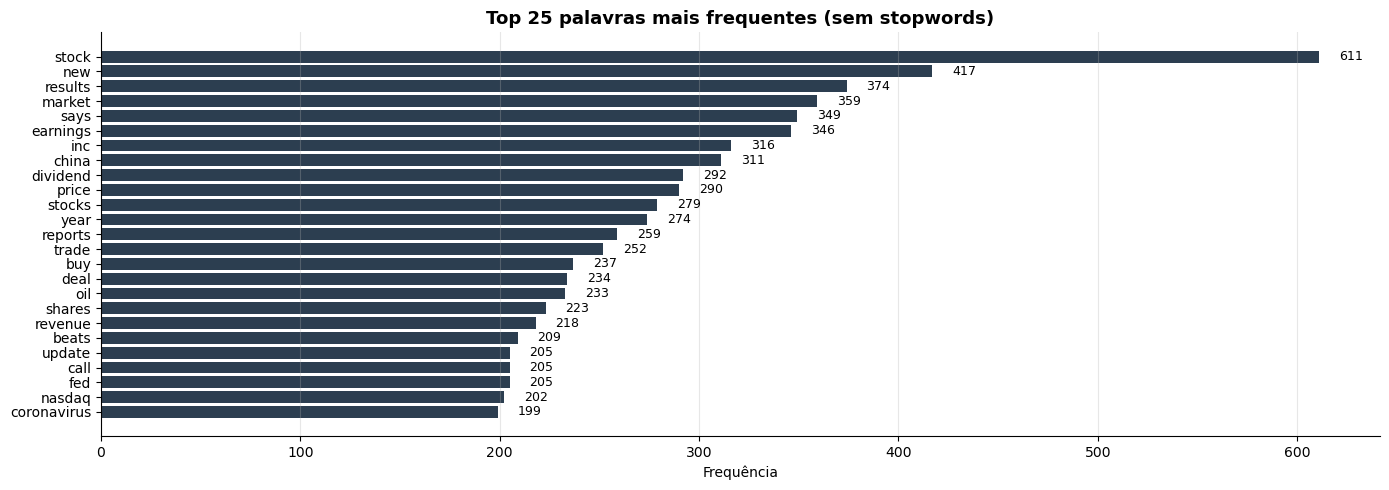

In [ ]:
# ── Bar chart top 25 palavras ─────────────────────────────────────────────────
top25_words, top25_counts = zip(*top50[:25])

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(list(reversed(top25_words)), list(reversed(top25_counts)),
               color='#2c3e50', edgecolor='none')
for bar, cnt in zip(bars, reversed(top25_counts)):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{cnt:,}', va='center', fontsize=9)
ax.set_title('Top 25 palavras mais frequentes (sem stopwords)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frequência')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 5. Top Palavras Específicas por Classe

Aqui identificamos palavras que são **distintivas** de cada classe — frequentes numa classe mas raras nas outras.

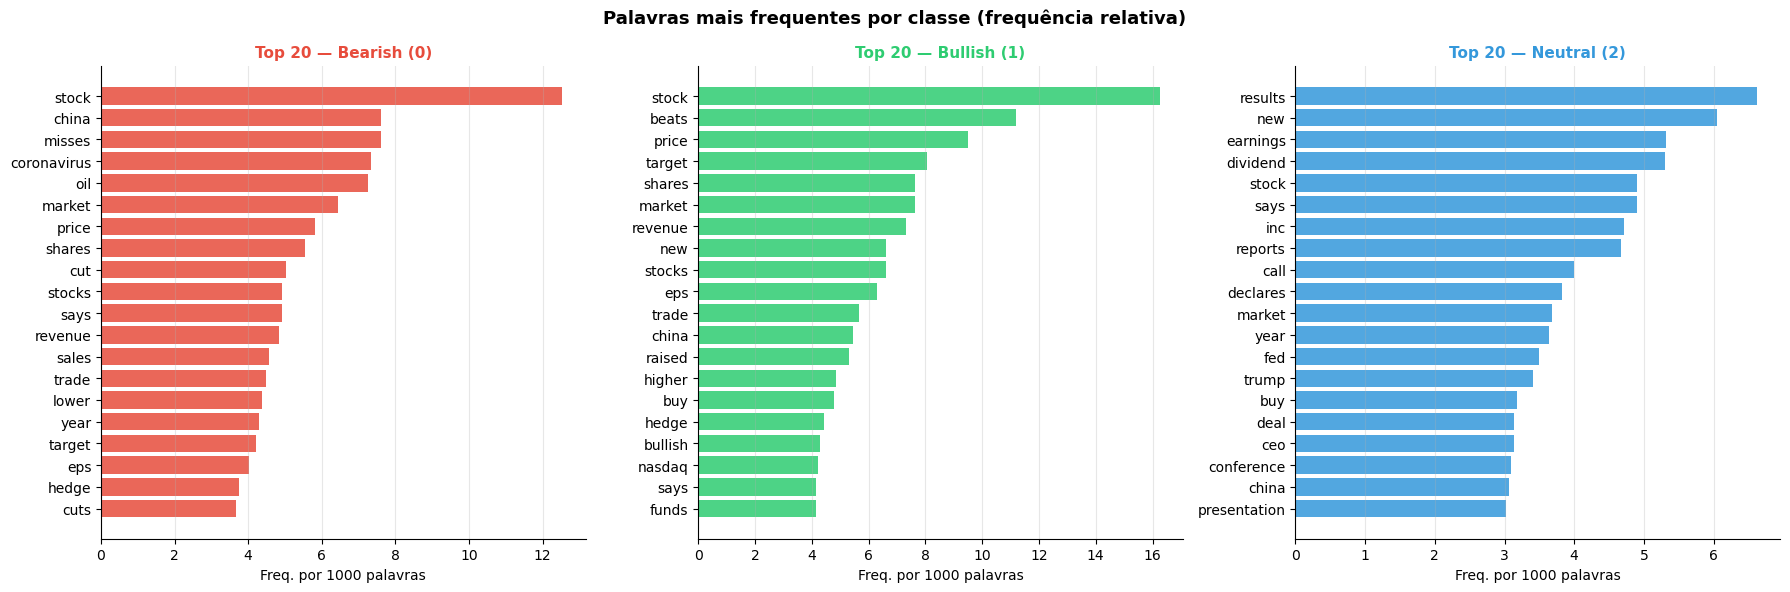

In [ ]:
# ── Top palavras por classe (frequência relativa) ─────────────────────────────
tokens_per_class = {}
for lbl in [0, 1, 2]:
    toks = []
    for txt in df[df['label'] == lbl]['text']:
        toks.extend(tokenize_clean(txt))
    tokens_per_class[lbl] = Counter(toks)

total_per_class = {lbl: sum(c.values()) for lbl, c in tokens_per_class.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for lbl, ax in zip([0, 1, 2], axes):
    # Frequência relativa (por 1000 palavras)
    rel_freq = {w: cnt / total_per_class[lbl] * 1000
                for w, cnt in tokens_per_class[lbl].items() if cnt >= 5}
    top_words = sorted(rel_freq, key=rel_freq.get, reverse=True)[:20]
    
    ax.barh(list(reversed(top_words)),
            [rel_freq[w] for w in reversed(top_words)],
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top 20 — {CLASS_NAMES[lbl]}', fontsize=11,
                 fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Freq. por 1000 palavras')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Palavras mais frequentes por classe (frequência relativa)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

word cloud

## 6. Análise de Características Especiais dos Tweets

In [12]:
# ── Hashtags, @mentions, URLs, números ───────────────────────────────────────
df['n_hashtags']  = df['text'].apply(lambda x: len(re.findall(r'#\w+', str(x))))
df['n_mentions']  = df['text'].apply(lambda x: len(re.findall(r'@\w+', str(x))))
df['n_urls']      = df['text'].apply(lambda x: len(re.findall(r'http\S+|www\S+', str(x))))
df['n_numbers']   = df['text'].apply(lambda x: len(re.findall(r'\b\d+\.?\d*%?\b', str(x))))
df['has_cashtag'] = df['text'].apply(lambda x: bool(re.search(r'\$[A-Z]{1,5}', str(x))))  # e.g. $AAPL

print('=== Presença média por tweet ===')
for feat in ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']:
    print(f'  {feat:<15}: {df[feat].mean():.2f} (max: {df[feat].max()})')
print(f'  Tweets com cashtag ($TICKER): {df["has_cashtag"].sum():,} ({df["has_cashtag"].mean()*100:.1f}%)')

# Por classe
print('\n=== Média por classe ===')
feat_by_class = df.groupby('label')[['n_hashtags','n_mentions','n_urls','n_numbers']].mean().round(2)
feat_by_class.index = [CLASS_NAMES[i] for i in feat_by_class.index]
print(feat_by_class)

=== Presença média por tweet ===
  n_hashtags     : 0.23 (max: 7)
  n_mentions     : 0.04 (max: 8)
  n_urls         : 0.53 (max: 3)
  n_numbers      : 0.50 (max: 12)
  Tweets com cashtag ($TICKER): 1,429 (15.0%)

=== Média por classe ===
             n_hashtags  n_mentions  n_urls  n_numbers
Bearish (0)        0.17        0.02    0.51       0.53
Bullish (1)        0.16        0.02    0.44       0.74
Neutral (2)        0.27        0.05    0.57       0.42


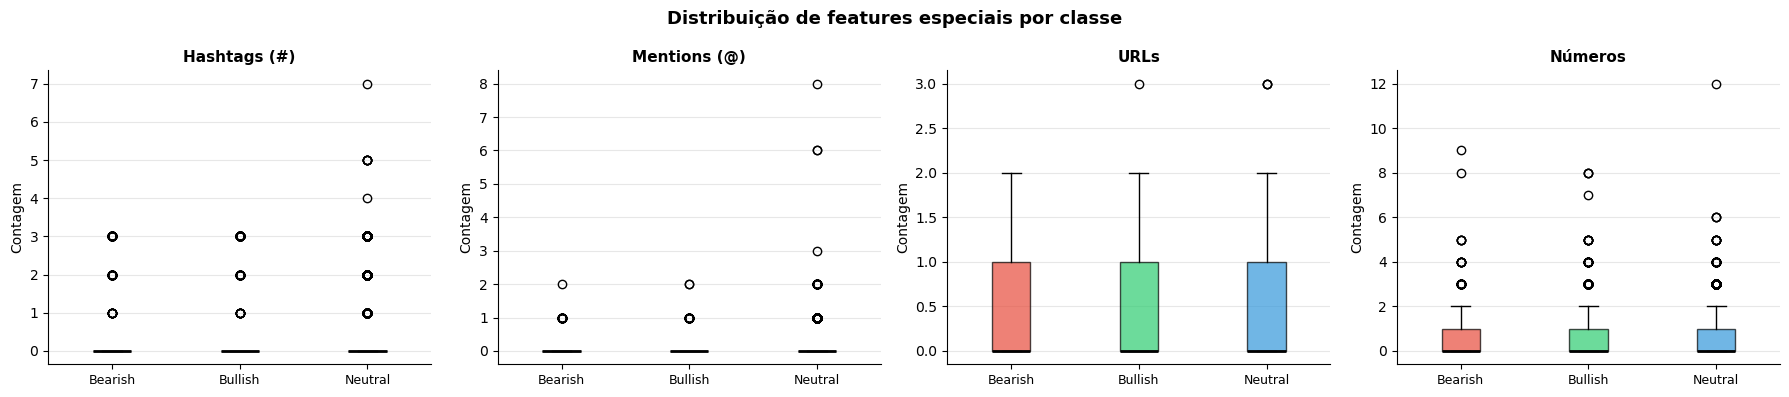

In [ ]:
# ── Visualização das features especiais por classe ───────────────────────────
features  = ['n_hashtags', 'n_mentions', 'n_urls', 'n_numbers']
feat_labels = ['Hashtags (#)', 'Mentions (@)', 'URLs', 'Números']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for feat, flabel, ax in zip(features, feat_labels, axes):
    data_by_class = [df[df['label'] == lbl][feat].values for lbl in [0,1,2]]
    bp = ax.boxplot(data_by_class, patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    for patch, lbl in zip(bp['boxes'], [0,1,2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'], fontsize=9)
    ax.set_title(flabel, fontsize=11, fontweight='bold')
    ax.set_ylabel('Contagem')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Distribuição de features especiais por classe', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Top Hashtags e Cashtags

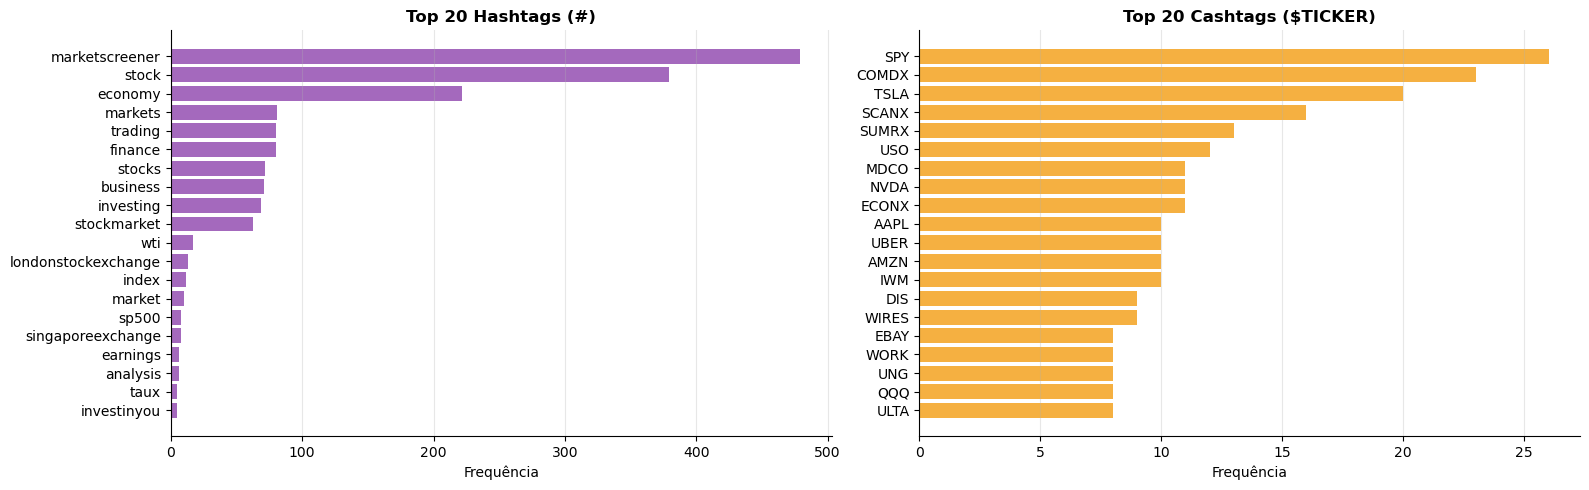

In [ ]:
# ── Hashtags mais comuns ──────────────────────────────────────────────────────
all_hashtags = []
for txt in df['text']:
    all_hashtags.extend(re.findall(r'#(\w+)', str(txt).lower()))

top_hashtags = Counter(all_hashtags).most_common(20)

all_cashtags = []
for txt in df['text']:
    all_cashtags.extend(re.findall(r'\$([A-Z]{1,5})', str(txt)))
top_cashtags = Counter(all_cashtags).most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

if top_hashtags:
    words_h, counts_h = zip(*top_hashtags)
    axes[0].barh(list(reversed(words_h)), list(reversed(counts_h)),
                 color='#8e44ad', edgecolor='none', alpha=0.8)
    axes[0].set_title('Top 20 Hashtags (#)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Frequência')
    axes[0].grid(axis='x', alpha=0.3)
    axes[0].spines[['top','right']].set_visible(False)

if top_cashtags:
    words_c, counts_c = zip(*top_cashtags)
    axes[1].barh(list(reversed(words_c)), list(reversed(counts_c)),
                 color='#f39c12', edgecolor='none', alpha=0.8)
    axes[1].set_title('Top 20 Cashtags ($TICKER)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequência')
    axes[1].grid(axis='x', alpha=0.3)
    axes[1].spines[['top','right']].set_visible(False)
else:
    axes[1].text(0.5, 0.5, 'Sem cashtags encontrados', ha='center', va='center', fontsize=12)
    axes[1].axis('off')

plt.tight_layout()
plt.show()

## 8. Heatmap de Co-ocorrência das Top Palavras

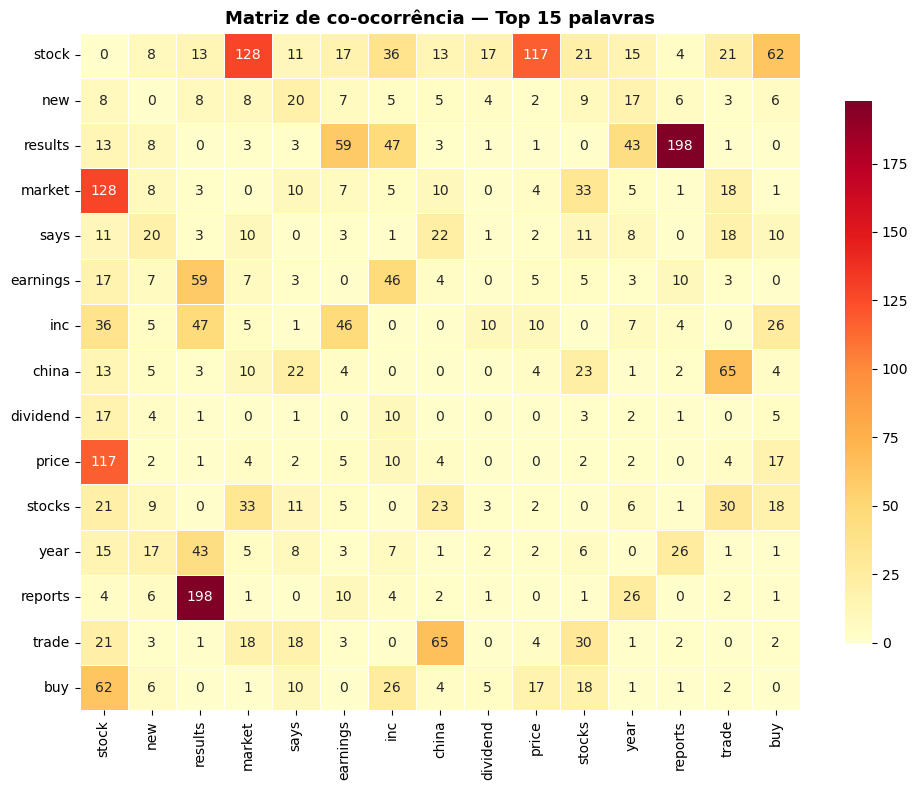

In [ ]:
# ── Matriz de co-ocorrência (top 15 palavras) ─────────────────────────────────
from itertools import combinations

top_words_list = [w for w, _ in freq.most_common(15)]
cooc = pd.DataFrame(0, index=top_words_list, columns=top_words_list)

for txt in df['text']:
    tokens = set(tokenize_clean(txt)) & set(top_words_list)
    for w1, w2 in combinations(tokens, 2):
        cooc.loc[w1, w2] += 1
        cooc.loc[w2, w1] += 1

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cooc, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Matriz de co-ocorrência — Top 15 palavras', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

existe 198 tewets que aparece em conjunto a palavra reports e results 

Secção 3 (N-gramas) — o resultado desta análise vai justificar diretamente uma decisão no Feature Engineering. Se vires bigramas como "beats earnings" no Bullish e "misses estimates" no Bearish, usas ngram_range=(1,2) no TF-IDF em vez de só unigramas.
Secção 4 (Comprimento) — inclui um teste estatístico de Kruskal-Wallis que te diz se a diferença de comprimento entre classes é significativa. Se o p-value for < 0.05, podes adicionar n_words como feature extra nos modelos.
Secção 6 (Temporal) — o código deteta automaticamente se existe coluna de data no teu CSV. Se não existir, imprime uma mensagem e passa à frente.
Secção 8 (Dispersão lexical) — o scatter plot mostra quais palavras aparecem distribuídas por muitos tweets vs concentradas em poucos. Isto justifica o parâmetro min_df no TF-IDF/BoW — palavras que aparecem em menos de 2-3 tweets não são boas features.

## 1. Análise de Sentimento com Palavras Financeiras

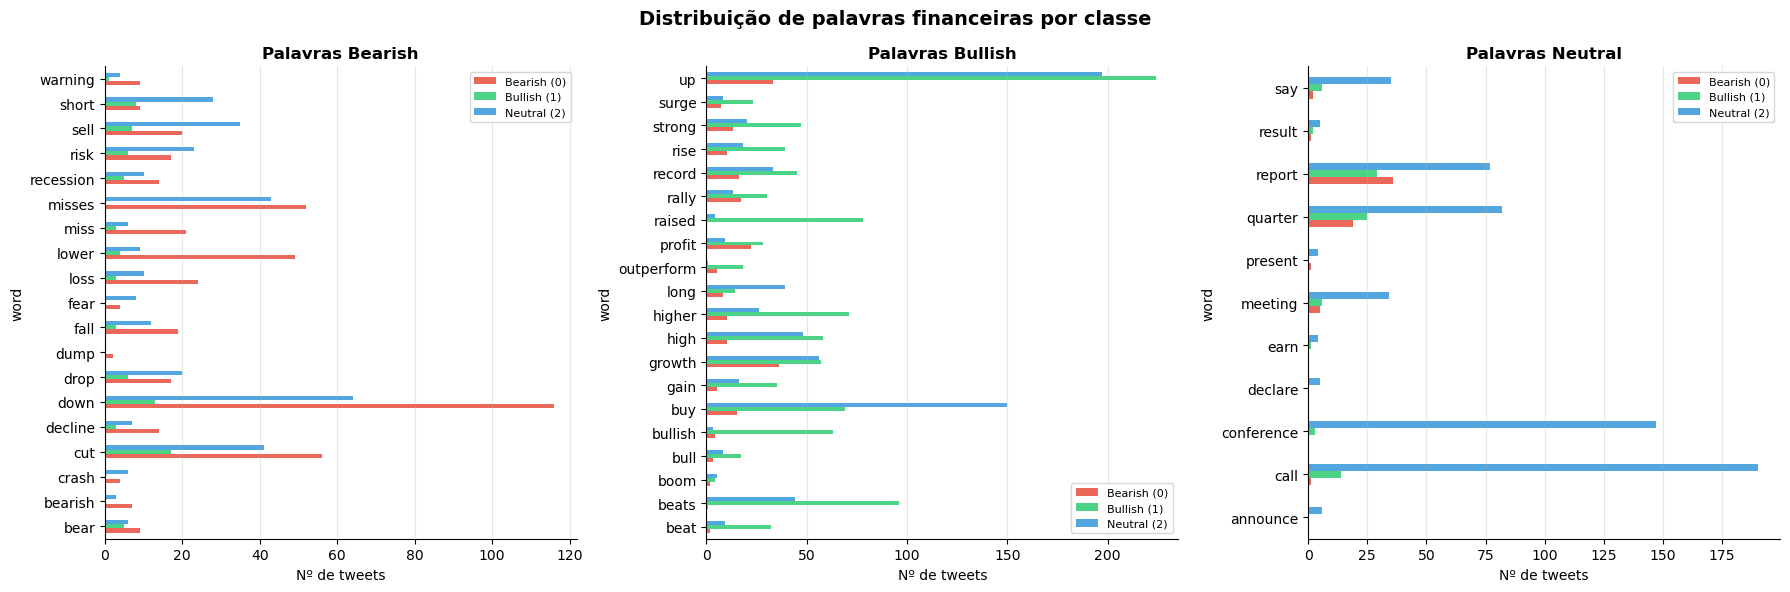

CONCLUSÃO: As palavras financeiras aparecem maioritariamente na classe esperada?
→ Se sim, o dataset é coerente e estas palavras serão boas features.


In [ ]:
# ── Palavras financeiras por classe ───────────────────────────────────────────
financial_words = {
    'Bearish': ['bear', 'bearish', 'crash', 'dump', 'fall', 'drop', 'loss',
                'decline', 'miss', 'misses', 'cut', 'lower', 'down', 'sell',
                'short', 'recession', 'fear', 'risk', 'warning'],
    'Bullish': ['bull', 'bullish', 'rally', 'rise', 'gain', 'surge', 'high',
                'beat', 'beats', 'raised', 'higher', 'buy', 'long', 'growth',
                'profit', 'record', 'boom', 'up', 'strong', 'outperform'],
    'Neutral': ['report', 'result', 'earn', 'announce', 'declare', 'say',
                'conference', 'meeting', 'call', 'present', 'quarter']
}

# Contar ocorrências de cada palavra por classe
results = []
for category, words in financial_words.items():
    for word in words:
        for lbl in [0, 1, 2]:
            count = df[df['label'] == lbl]['text'].str.lower().str.contains(
                rf'\b{word}\b', regex=True).sum()
            results.append({'category': category, 'word': word,
                            'class': CLASS_NAMES[lbl], 'count': count})

res_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (category, color) in zip(axes, [('Bearish','#e74c3c'),
                                          ('Bullish','#2ecc71'),
                                          ('Neutral','#3498db')]):
    cat_df = res_df[res_df['category'] == category]
    pivot  = cat_df.pivot(index='word', columns='class', values='count').fillna(0)
    pivot.plot(kind='barh', ax=ax,
               color=[CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]],
               edgecolor='none', alpha=0.85)
    ax.set_title(f'Palavras {category}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Nº de tweets')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8)

plt.suptitle('Distribuição de palavras financeiras por classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('CONCLUSÃO: As palavras financeiras aparecem maioritariamente na classe esperada?')
print('→ Se sim, o dataset é coerente e estas palavras serão boas features.')

## 3. Análise de N-gramas (Bigramas e Trigramas)

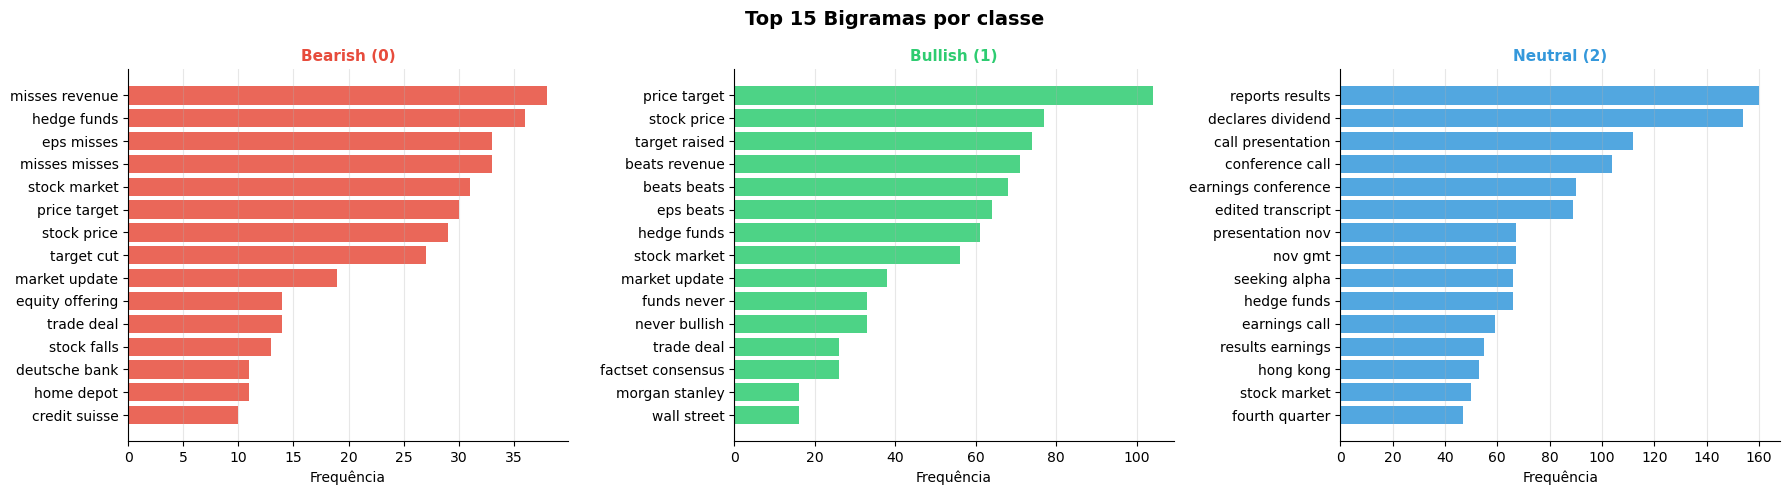

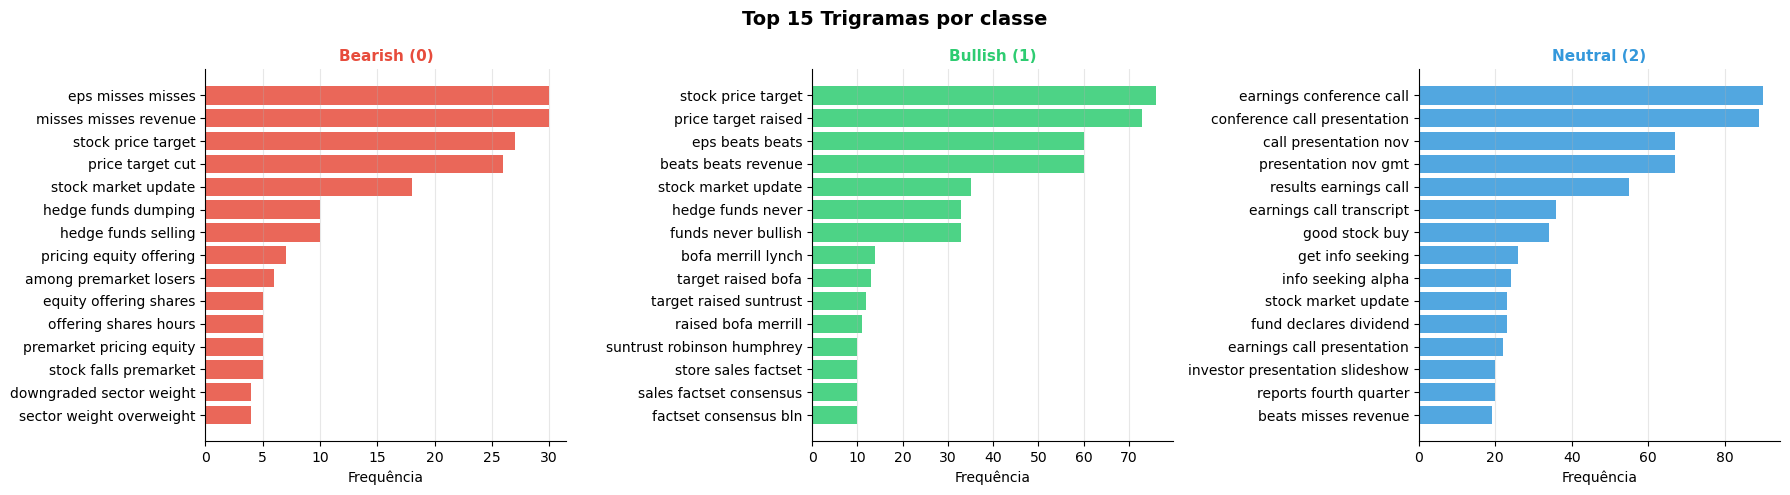

CONCLUSÃO: Vês bigramas como "beats earnings" no Bullish e "misses estimates" no Bearish?
→ Se sim, vale a pena usar ngram_range=(1,2) no TF-IDF.


In [ ]:
# ── N-gramas por classe ────────────────────────────────────────────────────────
from nltk.util import ngrams

def get_ngrams(texts, n):
    all_ngrams = []
    for text in texts:
        tokens = tokenize_clean(text)
        all_ngrams.extend([' '.join(g) for g in ngrams(tokens, n)])
    return Counter(all_ngrams)

for n, label_n in [(2, 'Bigramas'), (3, 'Trigramas')]:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for lbl, ax in zip([0, 1, 2], axes):
        ng = get_ngrams(df[df['label'] == lbl]['text'], n)
        top = ng.most_common(15)
        if top:
            words, counts = zip(*top)
            ax.barh(list(reversed(words)), list(reversed(counts)),
                    color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
        ax.set_title(f'{CLASS_NAMES[lbl]}', fontsize=11,
                     fontweight='bold', color=CLASS_COLORS[lbl])
        ax.set_xlabel('Frequência')
        ax.grid(axis='x', alpha=0.3)
        ax.spines[['top','right']].set_visible(False)
    plt.suptitle(f'Top 15 {label_n} por classe', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('CONCLUSÃO: Vês bigramas como "beats earnings" no Bullish e "misses estimates" no Bearish?')
print('→ Se sim, vale a pena usar ngram_range=(1,2) no TF-IDF.')

## 4. Comprimento dos Tweets por Classe (Boxplot)

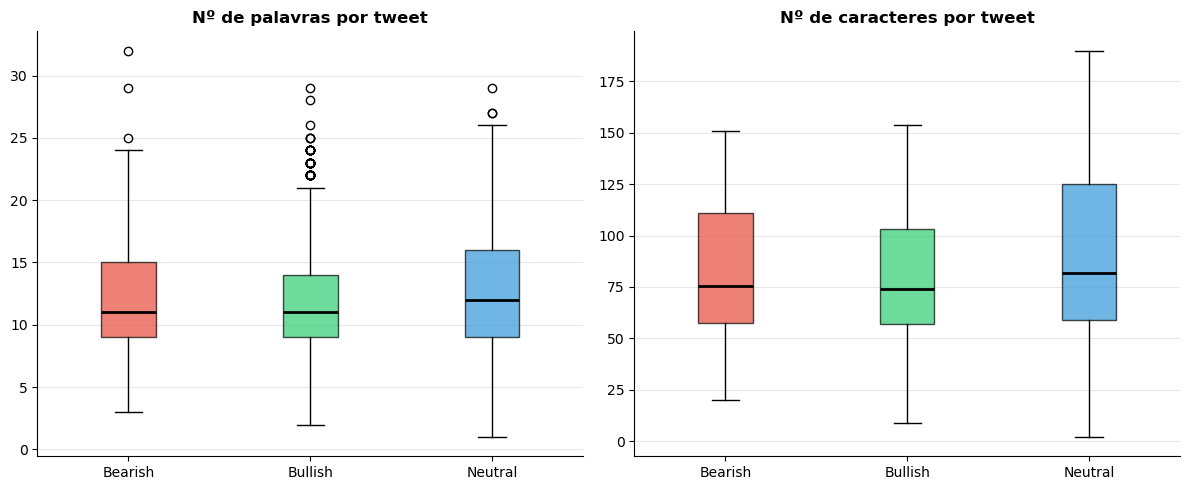

Kruskal-Wallis test (diferença de comprimento entre classes):
  p-value = 0.0113
  → Diferença estatisticamente significativa! O comprimento pode ser uma feature útil.

Média de palavras por classe:
label
Bearish (0)    12.0
Bullish (1)    11.9
Neutral (2)    12.3
Name: n_words, dtype: float64


In [ ]:
# ── Comprimento por classe ─────────────────────────────────────────────────────
df['n_words'] = df['text'].str.split().str.len()
df['n_chars'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for metric, ax, title in [
    ('n_words', axes[0], 'Nº de palavras por tweet'),
    ('n_chars',  axes[1], 'Nº de caracteres por tweet')
]:
    data   = [df[df['label'] == lbl][metric].values for lbl in [0, 1, 2]]
    bp     = ax.boxplot(data, patch_artist=True,
                        medianprops={'color': 'black', 'linewidth': 2})
    for patch, lbl in zip(bp['boxes'], [0, 1, 2]):
        patch.set_facecolor(CLASS_COLORS[lbl])
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Bearish', 'Bullish', 'Neutral'], fontsize=10)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Teste estatístico para ver se a diferença é significativa
from scipy import stats
bear = df[df['label'] == 0]['n_words']
bull = df[df['label'] == 1]['n_words']
neut = df[df['label'] == 2]['n_words']

stat, p = stats.kruskal(bear, bull, neut)
print(f'Kruskal-Wallis test (diferença de comprimento entre classes):')
print(f'  p-value = {p:.4f}')
if p < 0.05:
    print('  → Diferença estatisticamente significativa! O comprimento pode ser uma feature útil.')
else:
    print('  → Sem diferença significativa. O comprimento não discrimina bem as classes.')

print(f'\nMédia de palavras por classe:')
print(df.groupby('label')['n_words'].mean().round(1).rename(index=CLASS_NAMES))

## 5. Tweets sem Conteúdo Útil após Limpeza

Tweets vazios após limpeza (0 tokens):      10
Tweets com menos de 3 tokens:               156
Tweets com conteúdo útil (≥3 tokens):       9,387


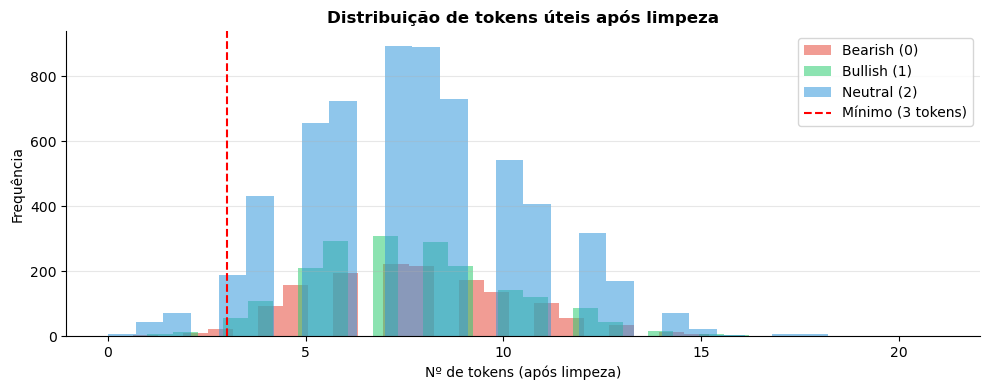


Exemplos de tweets problemáticos (< 3 tokens após limpeza):
                                                                                                                        text  label  n_tokens_clean
6                                                                              $GM - GM loses a bull https://t.co/tdUfG5HbXy      0               2
654                                        QE Infinity: So It Begins. https://t.co/HppY8KK3fV #business #stocks #stockmarket      2               2
1119                                                                        $LK calls @BlackBox_Team https://t.co/f0cvVLxwvW      2               1
1192                     AbbVie : Form 8.3 -  #AbbVie #Stock #MarketScreener https://t.co/QPZhKPWGjF https://t.co/AS7H0SkVG8      2               2
1612  JEOL : Form 8.3 - https://t.co/erBSsYuL00 #JEOL #Stock #MarketScreener https://t.co/Lt8CXiXJDy https://t.co/yVehgWa695      2               2
1692                     MongoDB : Form 10-Q #Mongo

In [ ]:
# ── Tweets vazios ou muito curtos após limpeza ────────────────────────────────
df['tokens_clean'] = df['text'].apply(tokenize_clean)
df['n_tokens_clean'] = df['tokens_clean'].str.len()

vazios       = (df['n_tokens_clean'] == 0).sum()
muito_curtos = (df['n_tokens_clean'] < 3).sum()

print(f'Tweets vazios após limpeza (0 tokens):      {vazios}')
print(f'Tweets com menos de 3 tokens:               {muito_curtos}')
print(f'Tweets com conteúdo útil (≥3 tokens):       {(df["n_tokens_clean"] >= 3).sum():,}')

# Distribuição do nº de tokens limpos
fig, ax = plt.subplots(figsize=(10, 4))
for lbl in [0, 1, 2]:
    subset = df[df['label'] == lbl]['n_tokens_clean']
    ax.hist(subset, bins=30, alpha=0.55,
            color=CLASS_COLORS[lbl], label=CLASS_NAMES[lbl], edgecolor='none')
ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='Mínimo (3 tokens)')
ax.set_title('Distribuição de tokens úteis após limpeza', fontsize=12, fontweight='bold')
ax.set_xlabel('Nº de tokens (após limpeza)')
ax.set_ylabel('Frequência')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

if muito_curtos > 0:
    print(f'\nExemplos de tweets problemáticos (< 3 tokens após limpeza):')
    mask = df['n_tokens_clean'] < 3
    print(df[mask][['text', 'label', 'n_tokens_clean']].head(10).to_string())

## 7. Palavras Exclusivas de Cada Classe


Bearish (0) — Top 20 palavras exclusivas (955 no total):
  plunges                 9
  sinks                   8
  tumble                  8
  downgrade               7
  tumbles                 6
  headwinds               6
  tumbled                 5
  cymabay                 5
  gamestop                5
  recalls                 4
  plummets                4
  cashing                 4
  hitting                 4
  underperform            4
  slashed                 4
  laundering              4
  sliding                 4
  lakewood                4
  eurozone                3
  slashes                 3

Bullish (1) — Top 20 palavras exclusivas (1165 no total):
  climbs                 11
  jumped                  8
  levi                    6
  inpx                    6
  ounce                   5
  intercept               5
  bounces                 5
  icpt                    5
  hasbro                  5
  aquestive               4
  bcf                     4
  climbed      

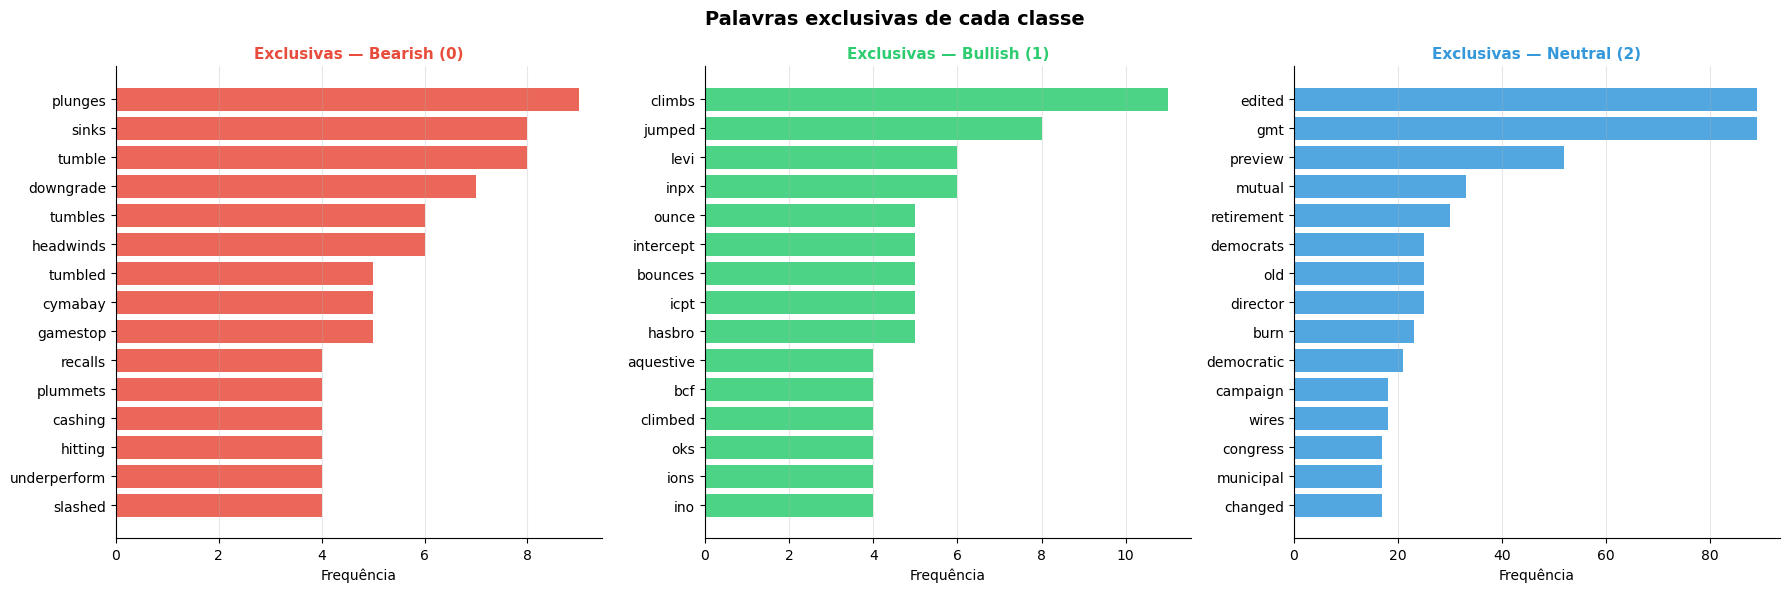

In [ ]:
# ── Vocabulário exclusivo por classe ──────────────────────────────────────────
vocab_per_class = {}
freq_per_class  = {}

for lbl in [0, 1, 2]:
    tokens = []
    for text in df[df['label'] == lbl]['text']:
        tokens.extend(tokenize_clean(text))
    vocab_per_class[lbl] = set(tokens)
    freq_per_class[lbl]  = Counter(tokens)

# Palavras que aparecem APENAS numa classe
for lbl in [0, 1, 2]:
    others  = set().union(*[vocab_per_class[l] for l in [0,1,2] if l != lbl])
    exclusive = vocab_per_class[lbl] - others
    # ordenar por frequência
    top_excl = sorted(exclusive, key=lambda w: freq_per_class[lbl][w], reverse=True)[:20]
    print(f'\n{CLASS_NAMES[lbl]} — Top 20 palavras exclusivas ({len(exclusive)} no total):')
    for w in top_excl:
        print(f'  {w:<20} {freq_per_class[lbl][w]:>4}')

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    others   = set().union(*[vocab_per_class[l] for l in [0,1,2] if l != lbl])
    exclusive = vocab_per_class[lbl] - others
    top_excl  = sorted(exclusive, key=lambda w: freq_per_class[lbl][w], reverse=True)[:15]
    counts    = [freq_per_class[lbl][w] for w in top_excl]
    ax.barh(list(reversed(top_excl)), list(reversed(counts)),
            color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Exclusivas — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequência')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Palavras exclusivas de cada classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Dispersão Lexical

Top 30 palavras — frequência total vs dispersão em tweets:
Palavra               Total  Nº tweets   % tweets  Ocorr/tweet
--------------------------------------------------------------
stock                   611        596       6.2%         1.03
new                     417        403       4.2%         1.03
results                 374        373       3.9%         1.00
market                  359        341       3.6%         1.05
says                    349        348       3.6%         1.00
earnings                346        345       3.6%         1.00
inc                     316        312       3.3%         1.01
china                   311        311       3.3%         1.00
dividend                292        287       3.0%         1.02
price                   290        290       3.0%         1.00
stocks                  279        277       2.9%         1.01
year                    274        259       2.7%         1.06
reports                 259        259       2.7%         1

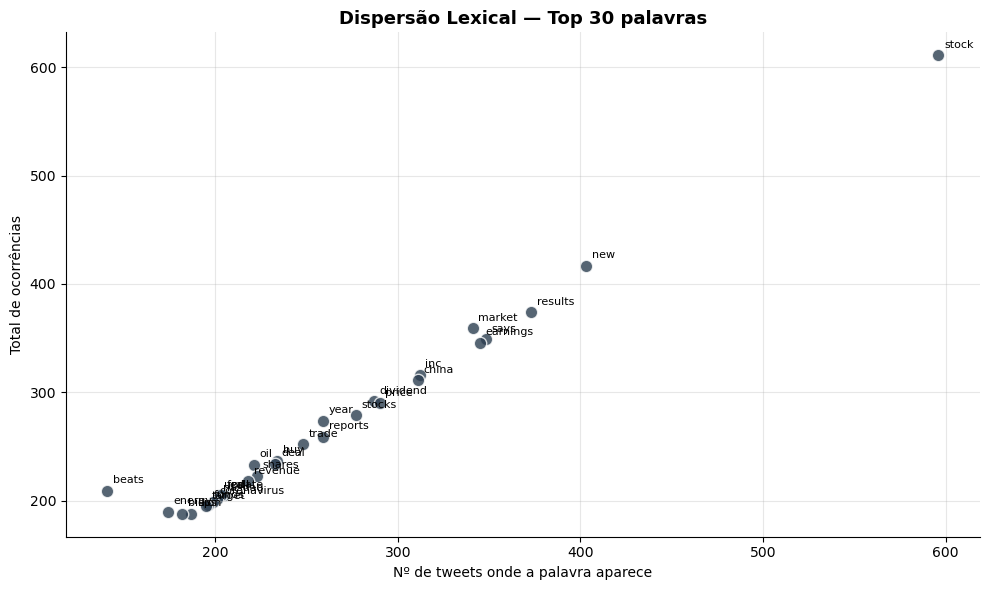


CONCLUSÃO:
Palavras próximas da diagonal (ocorr/tweet ≈ 1) aparecem uma vez por tweet → boas features.
Palavras muito acima da diagonal aparecem várias vezes no mesmo tweet → podem ser ruído.


In [ ]:
# ── Dispersão lexical ─────────────────────────────────────────────────────────
# Para cada palavra: em quantos tweets diferentes aparece?
from collections import defaultdict

word_doc_count = defaultdict(int)  # nº de tweets onde a palavra aparece
word_total     = Counter()          # nº total de ocorrências

for text in df['text']:
    tokens = set(tokenize_clean(text))  # set = conta 1 vez por tweet
    for t in tokens:
        word_doc_count[t] += 1

for text in df['text']:
    word_total.update(tokenize_clean(text))

# Top 30 palavras mais frequentes — ver dispersão
top30 = [w for w, _ in word_total.most_common(30)]

disp_df = pd.DataFrame({
    'palavra'     : top30,
    'total_ocorr' : [word_total[w] for w in top30],
    'n_tweets'    : [word_doc_count[w] for w in top30],
})
disp_df['ocorr_por_tweet'] = (disp_df['total_ocorr'] / disp_df['n_tweets']).round(2)
disp_df['pct_tweets']      = (disp_df['n_tweets'] / len(df) * 100).round(1)

print('Top 30 palavras — frequência total vs dispersão em tweets:')
print(f"{'Palavra':<18} {'Total':>8} {'Nº tweets':>10} {'% tweets':>10} {'Ocorr/tweet':>12}")
print('-' * 62)
for _, row in disp_df.iterrows():
    print(f"{row['palavra']:<18} {int(row['total_ocorr']):>8,} "
          f"{int(row['n_tweets']):>10,} {row['pct_tweets']:>9.1f}% "
          f"{row['ocorr_por_tweet']:>12.2f}")

# Scatter: total de ocorrências vs nº de tweets
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(disp_df['n_tweets'], disp_df['total_ocorr'],
           color='#2c3e50', s=80, alpha=0.8, edgecolors='white')
for _, row in disp_df.iterrows():
    ax.annotate(row['palavra'],
                (row['n_tweets'], row['total_ocorr']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Nº de tweets onde a palavra aparece')
ax.set_ylabel('Total de ocorrências')
ax.set_title('Dispersão Lexical — Top 30 palavras', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print('\nCONCLUSÃO:')
print('Palavras próximas da diagonal (ocorr/tweet ≈ 1) aparecem uma vez por tweet → boas features.')
print('Palavras muito acima da diagonal aparecem várias vezes no mesmo tweet → podem ser ruído.')

In [23]:
# ── Tweets com emojis ─────────────────────────────────────────────────────────
emoji_pattern = re.compile("["
    u"\U0001F600-\U0001F64F"  # emoticons
    u"\U0001F300-\U0001F5FF"  # símbolos e pictogramas
    u"\U0001F680-\U0001F6FF"  # transporte e mapas
    u"\U0001F1E0-\U0001F1FF"  # bandeiras
    u"\U00002700-\U000027BF"  # dingbats
    u"\U0001F900-\U0001F9FF"  # símbolos suplementares
"]+", flags=re.UNICODE)

df['has_emoji'] = df['text'].apply(lambda x: bool(emoji_pattern.search(str(x))))

print(f'Tweets com emojis: {df["has_emoji"].sum()} ({df["has_emoji"].mean()*100:.1f}%)')
print(f'\nPor classe:')
print(df.groupby('label')['has_emoji'].sum().rename(index=CLASS_NAMES))
print()
print('Exemplos de tweets com emojis:')
print(df[df['has_emoji']]['text'].head(10).to_string())

Tweets com emojis: 31 (0.3%)

Por classe:
label
Bearish (0)     0
Bullish (1)     1
Neutral (2)    30
Name: has_emoji, dtype: int64

Exemplos de tweets com emojis:
451     eib: #MustRead➡️EIB Bank Lending #Survey for #...
1388    Costco is selling special avocados that stay r...
3973    ❄@GitHub is storing open source code in an Arc...
3993    3 key pillars to ensure school infrastructure ...
4844    Meet @EelectricMiguel, an electric eel powerin...
4854                  Might have to do one of these.... 🤔
4895    NEW Global Electrification Platform, a one-sto...
5052    Scientists and citizens around the world are p...
5119    Swing trade ideas for this short week - Happy ...
5194    The first big check @Pitbull ever received act...


In [27]:
# ── Tweets com 1, 2 ou 3 palavras ────────────────────────────────────────────
df['text'] = df['text'].apply(tokenize_clean)
df['n_words'] = df['text'].str.len()

for n in [1]:
    subset = df[df['n_words'] == n]
    print(f'\n{"="*60}')
    print(f'Tweets com exatamente {n} palavra(s): {len(subset)}')
    print(f'Por classe:')
    print(subset['label'].value_counts().rename(index=CLASS_NAMES))
    print(f'\nExemplos:')
    print(subset['text'].head(10).to_string())


Tweets com exatamente 1 palavra(s): 54
Por classe:
label
Neutral (2)    43
Bullish (1)     7
Bearish (0)     4
Name: count, dtype: int64

Exemplos:
1119        [calls]
3090        [brent]
3641         [euro]
3708         [sell]
3881         [time]
3945    [sometimes]
3980      [correct]
4360         [damn]
4869        [later]
5150        [folks]


In [31]:
# ── Tweets com 1, 2 ou 3 palavras ──────────────────────────────────────────── 
df['text'] = df['text'].apply(tokenize_clean)
df['n_words'] = df['text'].str.len()

for n in [2]:
    subset = df[df['n_words'] == n]
    print(f'\n{"="*60}')
    print(f'Tweets com exatamente {n} palavra(s): {len(subset)}')
    print(f'Por classe:')
    print(subset['label'].value_counts().rename(index=CLASS_NAMES))
    print(f'\nExemplos:')
    print(subset['text'].head(10).to_string())


Tweets com exatamente 2 palavra(s): 92
Por classe:
label
Neutral (2)    70
Bullish (1)    13
Bearish (0)     9
Name: count, dtype: int64

Exemplos:
6                 [loses, bull]
654          [infinity, begins]
1192             [abbvie, form]
1612               [jeol, form]
1692            [mongodb, form]
1858                [sasa, pta]
2831    [worthington, earnings]
3342           [philip, morris]
3440          [disney, revenue]
3691               [euro, flat]


In [32]:
# ── Tweets com 1, 2 ou 3 palavras ────────────────────────────────────────────
df['n_words'] = df['text'].str.split().str.len()

for n in [3]:
    subset = df[df['n_words'] == n]
    print(f'\n{"="*60}')
    print(f'Tweets com exatamente {n} palavra(s): {len(subset)}')
    print(f'Por classe:')
    print(subset['label'].value_counts().rename(index=CLASS_NAMES))
    print(f'\nExemplos:')
    print(subset['text'].head(10).to_string())


Tweets com exatamente 3 palavra(s): 0
Por classe:
Series([], Name: count, dtype: int64)

Exemplos:
Series([], )


=== Média de palavras em MAIÚSCULAS por classe ===
             n_caps_words  n_caps_chars  pct_caps_words
label                                                  
Bearish (0)          0.58          8.10            5.27
Bullish (1)          0.62          8.01            5.63
Neutral (2)          0.62         10.04            5.99

Exemplos de tweets com palavras em maiúsculas:
                                                                                                                                  text_no_cashtag  label
74                                                                                    Hexo stock price target cut to C$5 from C$6 at MKM Partners      0
130                                                                                 *S&P Raises Centene Corp. Rtg To BBB- From BB+; Outlk Stable*      1
217                                                                                        CITRON SAYS IT'S LONG ON LUCKIN COFFEE\n\nMW vs CItron      1
235      

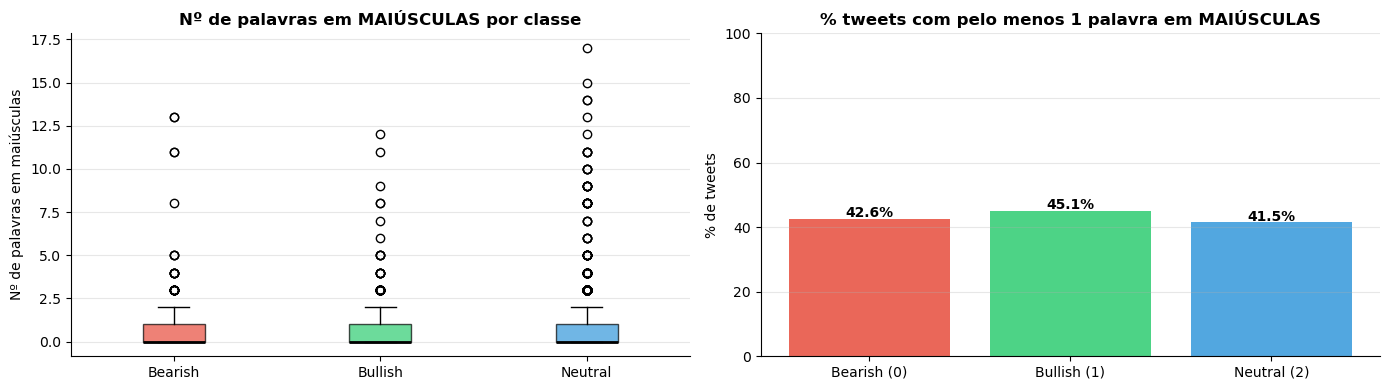


Kruskal-Wallis test: p-value = 0.1042
→ Sem diferença significativa. Podes fazer lowercase sem perder informação.


In [ ]:
# Recarregar o CSV original
df_original = pd.read_csv('train.csv')

# Remover cashtags antes da análise de maiúsculas para não contar tickers como palavras em caps
df_original['text_no_cashtag'] = df_original['text'].str.replace(r'\$[A-Za-z]{1,5}', ' ', regex=True)

# ── Palavras em maiúsculas por classe ─────────────────────────────────────────
df_original['n_caps_words'] = df_original['text_no_cashtag'].apply(
    lambda x: sum(1 for w in str(x).split() if w.isupper() and len(w) > 1)
)
df_original['n_caps_chars'] = df_original['text_no_cashtag'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper())
)
df_original['pct_caps_words'] = df_original.apply(
    lambda row: row['n_caps_words'] / len(str(row['text_no_cashtag']).split()) * 100 
    if len(str(row['text_no_cashtag']).split()) > 0 else 0, axis=1
)

# Estatísticas por classe
print('=== Média de palavras em MAIÚSCULAS por classe ===')
print(df_original.groupby('label')[['n_caps_words', 'n_caps_chars', 'pct_caps_words']]
        .mean().round(2).rename(index=CLASS_NAMES))

# Exemplos de tweets com muitas maiúsculas
print('\nExemplos de tweets com palavras em maiúsculas:')
print(df_original[df_original['n_caps_words'] >= 3][['text_no_cashtag', 'label']].head(10).to_string())

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Boxplot por classe
data = [df_original[df_original['label'] == lbl]['n_caps_words'].values for lbl in [0, 1, 2]]
bp = axes[0].boxplot(data, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, lbl in zip(bp['boxes'], [0, 1, 2]):
    patch.set_facecolor(CLASS_COLORS[lbl])
    patch.set_alpha(0.7)
axes[0].set_xticklabels(['Bearish', 'Bullish', 'Neutral'])
axes[0].set_title('Nº de palavras em MAIÚSCULAS por classe', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Nº de palavras em maiúsculas')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)

# Percentagem de tweets com pelo menos 1 palavra em maiúsculas
pct_com_caps = df_original.groupby('label').apply(
    lambda g: (g['n_caps_words'] > 0).mean() * 100
).rename(index=CLASS_NAMES)
bars = axes[1].bar(pct_com_caps.index, pct_com_caps.values,
                   color=[CLASS_COLORS[0], CLASS_COLORS[1], CLASS_COLORS[2]],
                   edgecolor='none', alpha=0.85)
for bar, val in zip(bars, pct_com_caps.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('% tweets com pelo menos 1 palavra em MAIÚSCULAS', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% de tweets')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

# Teste estatístico
from scipy import stats
groups = [df_original[df_original['label'] == lbl]['n_caps_words'] for lbl in [0, 1, 2]]
stat, p = stats.kruskal(*groups)
print(f'\nKruskal-Wallis test: p-value = {p:.4f}')
if p < 0.05:
    print('→ Diferença significativa! Maiúsculas podem ser uma feature útil — considera NÃO fazer lowercase.')
else:
    print('→ Sem diferença significativa. Podes fazer lowercase sem perder informação.')

=== Top 15 @mentions por classe ===

Bearish (0):
  @business                     6
  @bopinion                     2
  @tradingnation                2
  @edludlow                     1
  @cmegroup                     1
  @tonythestreet                1
  @oscarwgrut                   1
  @gitagopinath                 1
  @breakingviews                1
  @invescous                    1
  @newconstructs                1
  @jefferies                    1
  @davidfickling                1
  @iata                         1
  @guardian                     1

Bullish (1):
  @tradingnation                7
  @business                     3
  @here                         3
  @suntrust                     2
  @emily_mcck                   2
  @yahoofinance                 1
  @heidi_chung                  1
  @anjkhem                      1
  @wellsfargo                   1
  @giteshpandya                 1
  @samro                        1
  @goldmansachs                 1
  @carlquintanilla

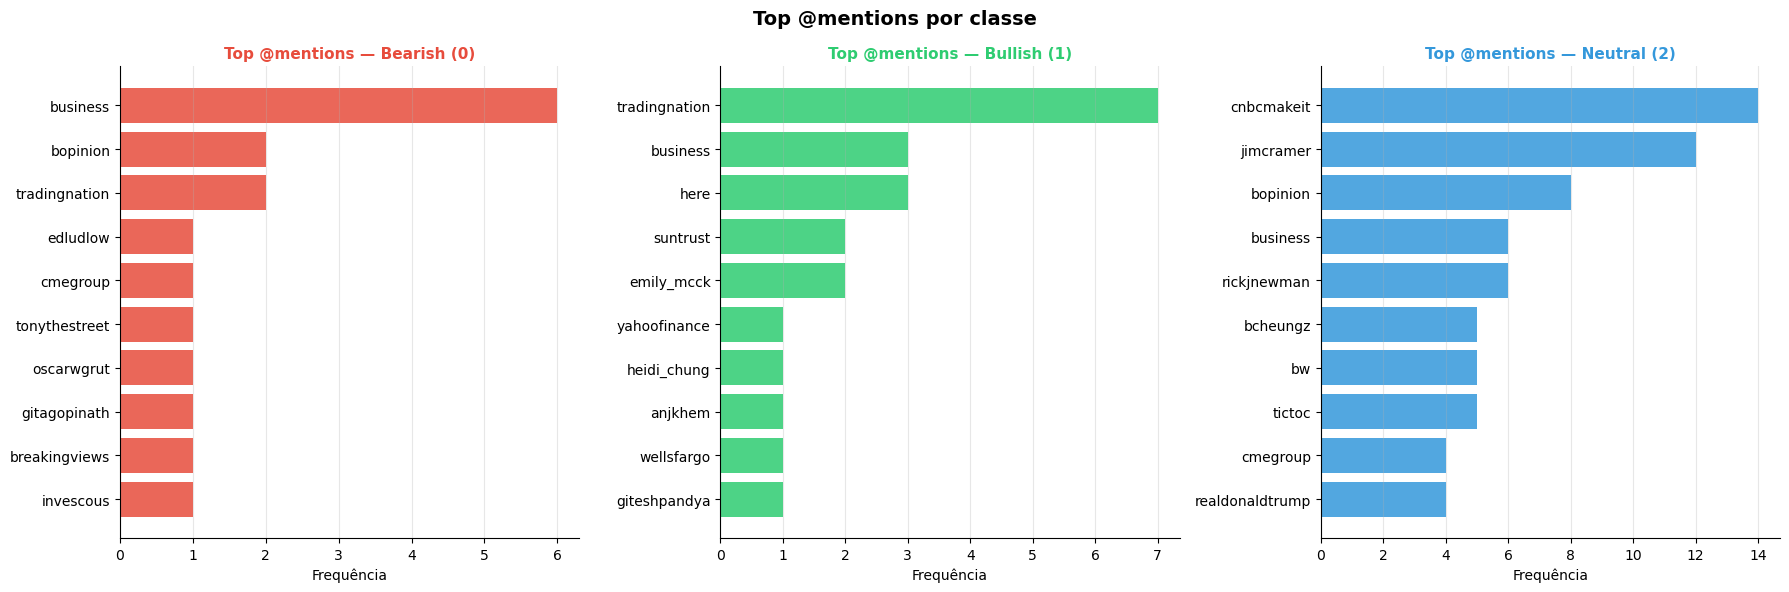

=== Mentions comuns entre classes (pouco discriminativos) ===
Mentions que aparecem nas 3 classes: 2
Exemplos: ['business', 'heidi_chung']

=== Mentions exclusivos de cada classe (muito discriminativos) ===
Bearish (0): 13 mentions exclusivos → ['guardian', 'tonythestreet', 'kansascityfed', 'invescous', 'newconstructs', 'gitagopinath', 'edludlow', 'iata', 'fournierwire', 'inesreports']
Bullish (1): 12 mentions exclusivos → ['cfraresearch', 'samro', 'carlquintanilla', 'goldmansachs', 'argusresearch', 'rbradthomas', 'suntrust', 'here', 'anjkhem', '1']
Neutral (2): 167 mentions exclusivos → ['linkedinecon', 'nasdaqcorpgov', 'ejcacciatore', 'sarge986', 'eelectricmiguel', 'sibiletv', 'readdanwrite', 'sweetgreen', 'pitbull', 'jason_buck']

=== CONCLUSÃO ===
Total de @mentions no dataset: 347
Tweets com pelo menos 1 @mention: 294 (3.1%)

→ Existem mentions exclusivos de cada classe.
→ DECISÃO RECOMENDADA: manter @mentions — são informativos.


In [ ]:
# ── @Mentions por classe ───────────────────────────────────────────────────────
df_original = pd.read_csv('train.csv')

# Extrair todos os @mentions
def get_mentions(text):
    return re.findall(r'@(\w+)', str(text).lower())

df_original['mentions'] = df_original['text'].apply(get_mentions)
df_original['n_mentions'] = df_original['mentions'].str.len()

# Top mentions por classe
print('=== Top 15 @mentions por classe ===\n')
for lbl in [0, 1, 2]:
    subset = df_original[df_original['label'] == lbl]['mentions']
    all_mentions = [m for mentions in subset for m in mentions]
    top = Counter(all_mentions).most_common(15)
    print(f'{CLASS_NAMES[lbl]}:')
    if top:
        for mention, cnt in top:
            print(f'  @{mention:<25} {cnt:>4}')
    else:
        print('  Sem mentions')
    print()

# Visualização — top 10 por classe
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset = df_original[df_original['label'] == lbl]['mentions']
    all_mentions = [m for mentions in subset for m in mentions]
    top = Counter(all_mentions).most_common(10)
    if top:
        words, counts = zip(*top)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top @mentions — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequência')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Top @mentions por classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Mentions que aparecem em MAIS DO QUE UMA classe — não são discriminativos
print('=== Mentions comuns entre classes (pouco discriminativos) ===')
mentions_per_class = {}
for lbl in [0, 1, 2]:
    subset = df_original[df_original['label'] == lbl]['mentions']
    all_m  = [m for mentions in subset for m in mentions]
    mentions_per_class[lbl] = set(all_m)

comuns = mentions_per_class[0] & mentions_per_class[1] & mentions_per_class[2]
print(f'Mentions que aparecem nas 3 classes: {len(comuns)}')
print(f'Exemplos: {list(comuns)[:15]}')

print('\n=== Mentions exclusivos de cada classe (muito discriminativos) ===')
for lbl in [0, 1, 2]:
    others    = set().union(*[mentions_per_class[l] for l in [0,1,2] if l != lbl])
    exclusive = mentions_per_class[lbl] - others
    print(f'{CLASS_NAMES[lbl]}: {len(exclusive)} mentions exclusivos → {list(exclusive)[:10]}')

# Conclusão automática
print('\n=== CONCLUSÃO ===')
total_mentions = sum(df_original['n_mentions'])
tweets_com_mention = (df_original['n_mentions'] > 0).sum()
print(f'Total de @mentions no dataset: {total_mentions:,}')
print(f'Tweets com pelo menos 1 @mention: {tweets_com_mention} ({tweets_com_mention/len(df_original)*100:.1f}%)')
print()
if len(comuns) > len(list(comuns_exclusivos := 
      set().union(*[mentions_per_class[l] - 
      set().union(*[mentions_per_class[ll] for ll in [0,1,2] if ll != l]) 
      for l in [0,1,2]]))):
    print('→ A maioria dos mentions aparece em várias classes.')
    print('→ DECISÃO RECOMENDADA: remover @mentions — são ruído.')
else:
    print('→ Existem mentions exclusivos de cada classe.')
    print('→ DECISÃO RECOMENDADA: manter @mentions — são informativos.')

como sao poucos chegamos a conclusao de retirar ,  porque nos estavamos com medo de         # VER NO DATA EXPLORATION QUAIS OS @ MAIS MENCIANDOS EM CADA LABEL SE HOUVER UMA DIFERENÇA SIGNIFICATIVA ENTRE AS LABELS, OU SE OS @MENTIONS FOREM UM INDICADOR CONFIÁVEL DE SENTIMENTO, ENTÃO PODE SER INTERESSANTE MANTER ESSA INFORMAÇÃO. POR EXEMPLO, SE "@ELONMUSK" APARECER MUITO EM BULLISH E "@SOMECRITIC" APARECER MUITO EM BEARISH, ISSO PODE SER UM SINAL FORTE DE SENTIMENTO. POR OUTRO LADO, SE NÃO HOUVER UMA DIFERENÇA CLARA, OU SE OS @MENTIONS NÃO FOREM UM INDICADOR CONFIÁVEL DE SENTIMENTO, ENTÃO PODE SER MELHOR REMOVER ESSA INFORMAÇÃO PARA REDUZIR O RUÍDO E O VOCABULÁRIO.


In [41]:
pip install wordsegment

   ---------------------------------------- 0.0/4.8 MB ? eta -:--:--
   ----------------- ---------------------- 2.1/4.8 MB 14.7 MB/s eta 0:00:01
   ---------------------------------------- 4.8/4.8 MB 13.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


=== Exemplos de segmentação de hashtags ===
  Original : ['samp', 'economy', 'marketscreener']
  Segmented: ['samp', 'economy', 'market', 'screener']

  Original : ['bankofnovascotia']
  Segmented: ['bank', 'of', 'nova', 'scotia']

  Original : ['fedreport', 'economy']
  Segmented: ['fed', 'report', 'economy']

  Original : ['economy', 'marketscreener']
  Segmented: ['economy', 'market', 'screener']

  Original : ['imfblog']
  Segmented: ['imf', 'blog']

  Original : ['economy', 'marketscreener']
  Segmented: ['economy', 'market', 'screener']

  Original : ['economy', 'marketscreener']
  Segmented: ['economy', 'market', 'screener']

  Original : ['economy', 'marketscreener']
  Segmented: ['economy', 'market', 'screener']

=== Top 15 palavras dentro de hashtags por classe ===

Bearish (0):
  market                 62
  screener               49
  economy                43
  stock                  29
  trading                16
  finance                15
  markets                14
  in

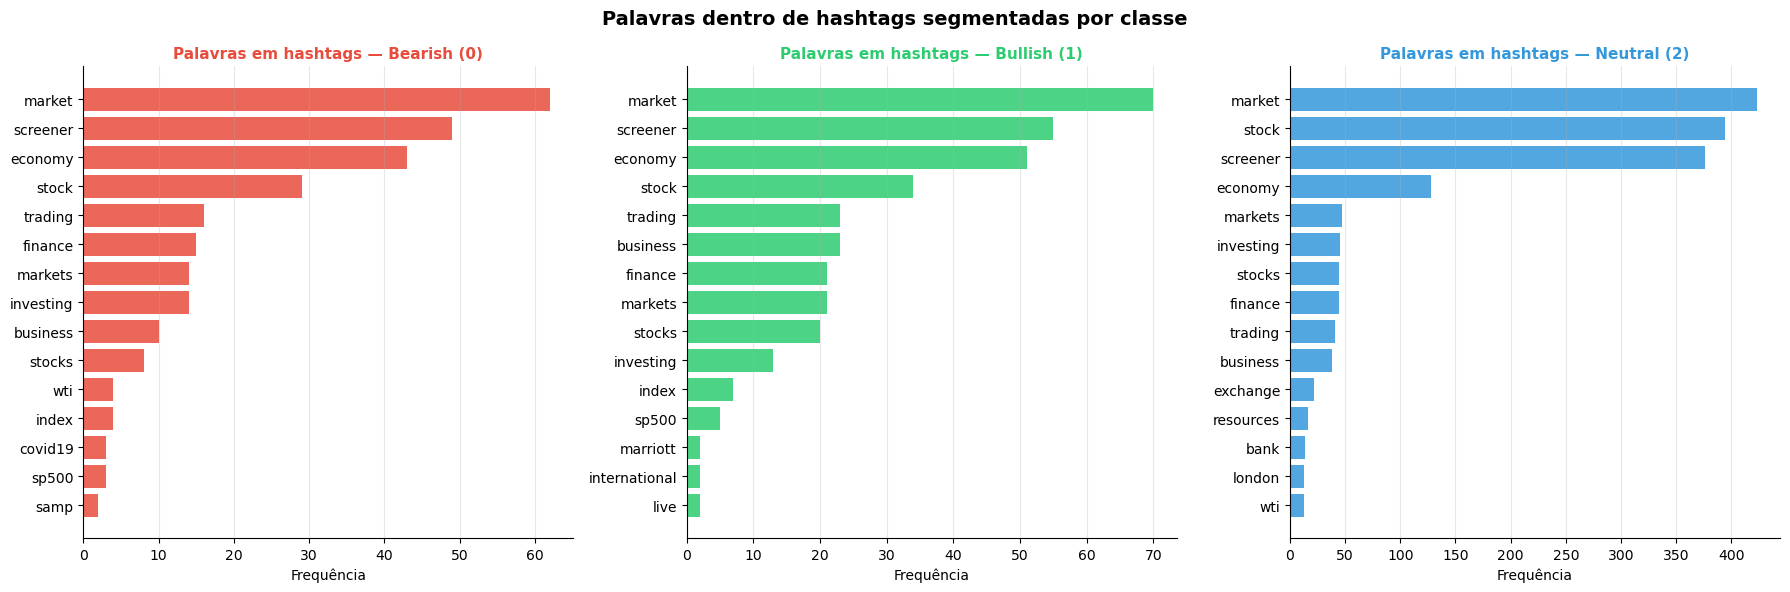

=== Palavras exclusivas dentro de hashtags por classe ===

Bearish (0): 20 palavras exclusivas
  Exemplos: ['cnooc', 'unilever', 'cyber', 'truck', 'investors', 'nutri', 'samsung', 'finnair', 'tax', 'gft', 'american', 'point', 'report', 'heavy', 'airbus']

Bullish (1): 32 palavras exclusivas
  Exemplos: ['ross', 'natural', 'exxonmobil', 'acceler', 'gdp', 'technology', 'baron', 'dividend', 'wallstreet', 'smarter', 'dowjones', 'musk', 'equity', 'elon', 'residential']

Neutral (2): 510 palavras exclusivas
  Exemplos: ['slice', 'milk', 'tel', 'therapeutics', 'read', 'taiwan', 'climate', 'cnbc', 'onix', 'gender', 'hitachi', 'imo', 'syn', 'gger', 'properties']

=== CONCLUSÃO ===
Se as palavras dentro dos hashtags são distintas por classe:
→ Vale a pena segmentar hashtags no preprocessing em vez de os remover.
→ Usar: re.sub(r"#(\w+)", lambda m: " ".join(segment(m.group(1))), text)

Se as palavras são maioritariamente comuns entre classes:
→ Basta manter a palavra inteira do hashtag (re.sub(r"

In [ ]:
# ── Hashtags segmentados por classe ───────────────────────────────────────────
from wordsegment import load, segment
from collections import Counter
import re

load()

def get_hashtag_words(text):
    """Extrai hashtags e segmenta cada uma em palavras."""
    hashtags = re.findall(r'#(\w+)', str(text).lower())
    words = []
    for tag in hashtags:
        words.extend(segment(tag))  # #stockmarketcrash → ['stock','market','crash']
    return words

df_original = pd.read_csv('train.csv')
df_original['hashtag_words'] = df_original['text'].apply(get_hashtag_words)
df_original['n_hashtags']    = df_original['text'].apply(
    lambda x: len(re.findall(r'#(\w+)', str(x)))
)

# Ver exemplos da segmentação
print('=== Exemplos de segmentação de hashtags ===')
mask = df_original['n_hashtags'] > 0
for _, row in df_original[mask].head(8).iterrows():
    hashtags_raw = re.findall(r'#(\w+)', str(row['text']).lower())
    print(f'  Original : {hashtags_raw}')
    print(f'  Segmented: {row["hashtag_words"]}')
    print()

# Top palavras dentro de hashtags por classe
print('=== Top 15 palavras dentro de hashtags por classe ===\n')
for lbl in [0, 1, 2]:
    subset   = df_original[df_original['label'] == lbl]['hashtag_words']
    all_words = [w for words in subset for w in words if len(w) > 2]
    top      = Counter(all_words).most_common(15)
    print(f'{CLASS_NAMES[lbl]}:')
    for word, cnt in top:
        print(f'  {word:<20} {cnt:>4}')
    print()

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset    = df_original[df_original['label'] == lbl]['hashtag_words']
    all_words = [w for words in subset for w in words if len(w) > 2]
    top       = Counter(all_words).most_common(15)
    if top:
        words, counts = zip(*top)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Palavras em hashtags — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequência')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Palavras dentro de hashtags segmentadas por classe',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Palavras exclusivas de cada classe dentro de hashtags
print('=== Palavras exclusivas dentro de hashtags por classe ===')
vocab_hashtag = {}
for lbl in [0, 1, 2]:
    subset    = df_original[df_original['label'] == lbl]['hashtag_words']
    all_words = set(w for words in subset for w in words if len(w) > 2)
    vocab_hashtag[lbl] = all_words

for lbl in [0, 1, 2]:
    others    = set().union(*[vocab_hashtag[l] for l in [0,1,2] if l != lbl])
    exclusive = vocab_hashtag[lbl] - others
    print(f'\n{CLASS_NAMES[lbl]}: {len(exclusive)} palavras exclusivas')
    print(f'  Exemplos: {list(exclusive)[:15]}')

# Conclusão
print('\n=== CONCLUSÃO ===')
print('Se as palavras dentro dos hashtags são distintas por classe:')
print('→ Vale a pena segmentar hashtags no preprocessing em vez de os remover.')
print('→ Usar: re.sub(r"#(\\w+)", lambda m: " ".join(segment(m.group(1))), text)')
print()
print('Se as palavras são maioritariamente comuns entre classes:')
print('→ Basta manter a palavra inteira do hashtag (re.sub(r"#(\\w+)", r"\\1", text))')

acho que vamos remover  porque as palavras que mais tem frequencia nos hastags   sao em comuns em todas as labels e depois as outras que nao sao em comum achamos que nao tinham uma frquencia significativa 

=== Top 15 cashtags por classe ===

Bearish (0):
  $USO                     7
  $NFLX                    4
  $UBER                    4
  $OIL                     4
  $LK                      3
  $GME                     3
  $ECONX                   3
  $SCANX                   3
  $ZM                      3
  $ESS                     2
  $GM                      2
  $GTT                     2
  $AAPL                    2
  $KRG                     2
  $MANT                    2

Bullish (1):
  $TSLA                    9
  $SPY                     8
  $NVDA                    7
  $SCANX                   7
  $SUMRX                   6
  $INPX                    6
  $ECONX                   5
  $LYFT                    4
  $AAPL                    4
  $DIS                     4
  $ICPT                    4
  $AMZN                    4
  $USO                     4
  $UNG                     4
  $IWM                     4

Neutral (2):
  $COMDX                  21
  $SPY                  

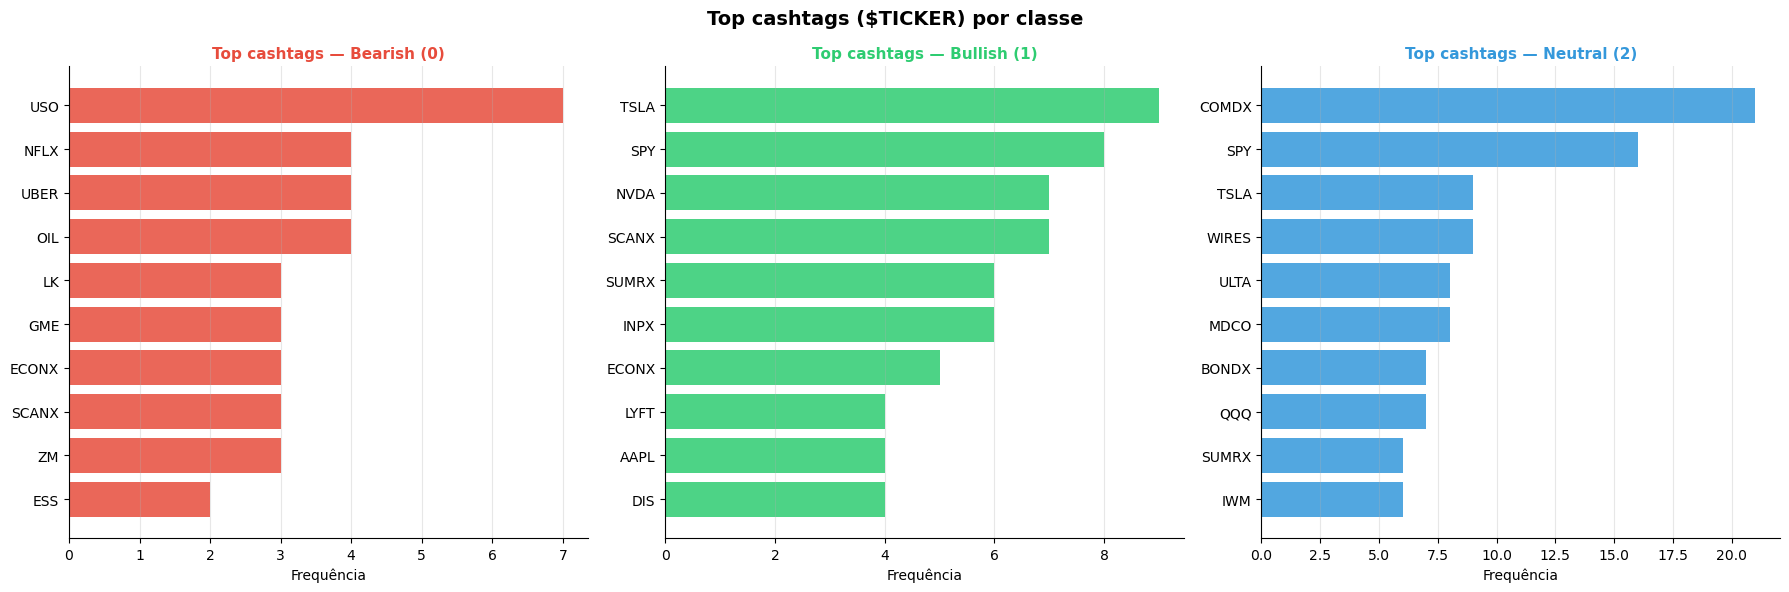

=== Cashtags comuns entre as 3 classes (pouco discriminativos) ===
Total: 34
Exemplos: ['AMZN', 'SPLK', 'BA', 'IQ', 'ECONX', 'MSFT', 'AMRH', 'USO', 'RNG', 'UGAZ', 'M', 'F', 'UNG', 'TSLA', 'UL']

=== Cashtags exclusivos de cada classe (discriminativos) ===
Bearish (0): 141 exclusivos → ['DEX', 'BZUN', 'MLND', 'AXAS', 'SHEN', 'KRG', 'CX', 'MPC', 'HNHAF', 'TBT']
Bullish (1): 279 exclusivos → ['PLTM', 'CANF', 'S', 'DE', 'HEPA', 'ZYXI', 'KERN', 'INDU', 'ESEA', 'EXR']
Neutral (2): 562 exclusivos → ['FET', 'EHTH', 'MSBHF', 'FOXA', 'PVG', 'SR', 'PFSI', 'MKD', 'WCAGY', 'VHC']

=== COBERTURA ===
Total de cashtags no dataset:          2,027
Tweets com pelo menos 1 cashtag:       1435 (15.0%)

Média de cashtags por tweet por classe:
label
Bearish (0)    0.216
Bullish (1)    0.341
Neutral (2)    0.171
Name: n_cashtags, dtype: float64

=== CONCLUSÃO ===
Se os mesmos tickers ($SPY, $TSLA) aparecem nas 3 classes:
→ O ticker em si não discrimina — substitui por TICKER no preprocessing.

Se há tickers e

In [ ]:
# ── Cashtags por classe ────────────────────────────────────────────────────────
df_original = pd.read_csv('train.csv')

# Extrair todos os cashtags ($TSLA, $AAPL, etc.)
def get_cashtags(text):
    return re.findall(r'\$([A-Za-z]{1,5})', str(text).upper())

df_original['cashtags']   = df_original['text'].apply(get_cashtags)
df_original['n_cashtags'] = df_original['cashtags'].str.len()

# Top cashtags por classe
print('=== Top 15 cashtags por classe ===\n')
for lbl in [0, 1, 2]:
    subset      = df_original[df_original['label'] == lbl]['cashtags']
    all_cash    = [c for cashtags in subset for c in cashtags]
    top         = Counter(all_cash).most_common(15)
    print(f'{CLASS_NAMES[lbl]}:')
    if top:
        for cash, cnt in top:
            print(f'  ${cash:<20} {cnt:>4}')
    else:
        print('  Sem cashtags')
    print()

# Visualização
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for lbl, ax in zip([0, 1, 2], axes):
    subset   = df_original[df_original['label'] == lbl]['cashtags']
    all_cash = [c for cashtags in subset for c in cashtags]
    top      = Counter(all_cash).most_common(10)
    if top:
        words, counts = zip(*top)
        ax.barh(list(reversed(words)), list(reversed(counts)),
                color=CLASS_COLORS[lbl], edgecolor='none', alpha=0.85)
    ax.set_title(f'Top cashtags — {CLASS_NAMES[lbl]}',
                 fontsize=11, fontweight='bold', color=CLASS_COLORS[lbl])
    ax.set_xlabel('Frequência')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Top cashtags ($TICKER) por classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cashtags comuns vs exclusivos
cashtags_per_class = {}
for lbl in [0, 1, 2]:
    subset   = df_original[df_original['label'] == lbl]['cashtags']
    all_cash = [c for cashtags in subset for c in cashtags]
    cashtags_per_class[lbl] = set(all_cash)

comuns = cashtags_per_class[0] & cashtags_per_class[1] & cashtags_per_class[2]
print(f'=== Cashtags comuns entre as 3 classes (pouco discriminativos) ===')
print(f'Total: {len(comuns)}')
print(f'Exemplos: {list(comuns)[:15]}')

print(f'\n=== Cashtags exclusivos de cada classe (discriminativos) ===')
for lbl in [0, 1, 2]:
    others    = set().union(*[cashtags_per_class[l] for l in [0,1,2] if l != lbl])
    exclusive = cashtags_per_class[lbl] - others
    print(f'{CLASS_NAMES[lbl]}: {len(exclusive)} exclusivos → {list(exclusive)[:10]}')

# Cobertura
print('\n=== COBERTURA ===')
total_cash        = sum(df_original['n_cashtags'])
tweets_com_cash   = (df_original['n_cashtags'] > 0).sum()
print(f'Total de cashtags no dataset:          {total_cash:,}')
print(f'Tweets com pelo menos 1 cashtag:       {tweets_com_cash} ({tweets_com_cash/len(df_original)*100:.1f}%)')
print(f'\nMédia de cashtags por tweet por classe:')
print(df_original.groupby('label')['n_cashtags'].mean().round(3).rename(index=CLASS_NAMES))

# Conclusão
print('\n=== CONCLUSÃO ===')
print('Se os mesmos tickers ($SPY, $TSLA) aparecem nas 3 classes:')
print('→ O ticker em si não discrimina — substitui por TICKER no preprocessing.')
print()
print('Se há tickers exclusivos de Bearish ou Bullish:')
print('→ Podem ser features úteis — considera manter os cashtags mais frequentes.')

Análises que faltam e porquê são úteis
1. Análise de Sentimento com palavras financeiras
Verificar se palavras como "bull", "bear", "rally", "crash", "dump" aparecem na classe correta — confirma que o dataset faz sentido e que essas palavras vão ser boas features.


3. Análise de N-gramas (bigramas e trigramas)
Em vez de palavras isoladas, ver pares e trios de palavras por classe:

Bearish: "stock falls", "misses earnings", "lower than expected"
Bullish: "beats earnings", "stock rises", "higher than expected"

Isto é importante porque "not good" em BoW parece positivo ("good") mas em bigrama é claramente negativo. Ajuda a decidir se usas bigramas no BoW.

4. Comprimento dos tweets por classe (boxplot)
Verificar se tweets Bearish tendem a ser mais longos/curtos que Bullish. Se houver diferença significativa, o comprimento pode ser uma feature adicional.

5. Tweets sem conteúdo útil após limpeza
Quantos tweets ficam vazios ou com menos de 3 palavras depois de remover URLs, mentions, stopwords? Esses tweets são problemáticos para os modelos e deves identificá-los agora.

6. Análise temporal (se houver coluna de data)
Se o teu train.csv tiver uma coluna de data, vale a pena ver se há períodos com mais tweets Bearish (ex: crash de mercado) — dá contexto rico para o relatório.

7. Palavras exclusivas de cada classe
Palavras que aparecem apenas numa classe e nunca nas outras — são as features mais discriminativas e justificam a escolha de modelos como TF-IDF.
pythonwords_only_in_bearish = vocab_bearish - vocab_bullish - vocab_neutral

8. Dispersão lexical
Ver se as palavras mais importantes aparecem distribuídas por muitos tweets ou estão concentradas em poucos. Uma palavra que aparece 500 vezes mas só em 3 tweets não é boa feature.

decidir se  metemos o corpus split antes do data pre processing ou depois do data pre processing , porque o claude diz para meter depois do pre processing , mas no enucniado do projeto esta antes do preprocessing 

# Pre processing
